# Lesson 2.8 — 草稿 notebook：环境、trajectory、expert planner 与 BC 部署

这是一个**工作用 notebook**，而不是整理过的课程。它保留了项目从"跑一个环境"到"部署一个 BC policy 并判定它失败"的完整路径，包括走过的弯路。内容分四轮写成：

1. **环境基础**（2.8.1–2.8.2）—— 构建 `PickCube-v1`，读取 42 维 observation，采样并 step 一个 action。
2. **随机 trajectory 采集**（2.8.3）—— 组装一个 transition 列表和一个完整 episode，同时确立 `(o_t, a_t)` 配对。
3. **寻找并构建 expert planner**（2.8.4–2.8.6）—— 在已安装的 ManiSkill 包中搜索 demonstration 生成器，转向 `pd_joint_pos`，并在 `embodied310` 中构造 planner。
4. **最小 BC 的评估与部署**（2.8.7–2.8.8）—— 按 episode 划分 train/validation、early stopping 与 baseline 比较，然后把最好的 checkpoint 放进闭环 rollout。

> **本 notebook 的最终结论.** 训练代码是正确的：训练 Loss 下降、验证集暴露过拟合、early stopping 保住最好的 epoch、baseline 比较说明没有泛化、action clipping 保证动作不越界、50 步与 200 步对照排除时间上限。因此这里的模型是一个**失败基线**（failure baseline），而不是可用 policy；要得到可用的 BC policy，下一轮需要把 expert 数据扩到至少 30–50 条 episode，而不是修改训练代码。完整证据见 2.8.7 与 2.8.8 两节。

> **关于顺序的说明。** 原文件末尾的三处 import 自检（`mplib`、`sapien`、planner 类）已被**上移**，放到它们所支撑的 planner 构建之前。它们的代码未变，记录的 outputs 也是原始结果，因此 `execution_count` 的取值现在看起来是乱序的。除此之外，cell 的 source 与 outputs 未作其他修改。

## 为什么 `pd_joint_pos` 会出现在中间

第一轮使用的是 `pd_joint_delta_pos`，也就是项目 dataset fixture 的控制模式。planner 后来拒绝了它：它的 gripper 辅助函数输出 `[qpos(7), gripper]`，即一个 8 维的 **absolute** 位置 action，因此 delta 模式的环境会失败并报 `Received action of shape torch.Size([15]) but expected shape (1, 8)`。后半部分切换到 `pd_joint_pos`，正是对这一发现过程的记录。

> **环境要求。** 构建 planner 需要 `mplib`，而它是针对 NumPy 1.x 的 C API 编译的。在 NumPy 2.x 的环境中，本 notebook 的 planner cell 会以 `SIGSEGV`（地址 `0x0`）终止 kernel。请在 `embodied310`（NumPy 1.26.4）下运行 planner 相关的 cells；参见 `notes/progress.md`。

成功路径的整理版本位于 `2.9_expert_demonstrations.ipynb`；批量采集器是 `scripts/generate_expert_demo.py`。


## 2.8.1 — 构建环境

三个参数决定了 agent 看到什么、做什么：

- `obs_mode="state"` —— 展平的 robot + object state vector，不含图像。
- `control_mode="pd_joint_delta_pos"` —— action 是**关节位置的变化量**，也就是项目 dataset fixture 使用的模式。（这是第一轮设置；2.8.5 会解释为什么 stock planner 要求改成 `pd_joint_pos`。）
- `render_mode="rgb_array"` —— 在 notebook 中无需 display server 即可工作。

In [1]:
import gymnasium as gym

import mani_skill.envs


# --------------------------------------------------
# Create PickCube environment
#
# obs_mode:
#   state = robot + object information
#
# control_mode:
#   pd_joint_delta_pos
#   means action controls joint position change
#
# render_mode:
#   rgb_array works better in notebook
# --------------------------------------------------

env = gym.make(
    "PickCube-v1",
    obs_mode="state",
    control_mode="pd_joint_delta_pos",
    render_mode="rgb_array",
)


print("Environment initialized")

print("Observation:")
print(env.observation_space)

print("Action:")
print(env.action_space)

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized
Observation:
Box(-inf, inf, (1, 42), float32)
Action:
Box(-1.0, 1.0, (8,), float32)


In [2]:
# --------------------------------------------------
# Reset simulator
#
# This creates:
# - physics scene
# - robot
# - objects
# - task state
# --------------------------------------------------

obs, info = env.reset()


print("Reset successful!")

print("Observation shape:")
print(obs.shape)

Reset successful!
Observation shape:
torch.Size([1, 42])


### Reset 并读取 42 维 observation

`env.reset()` 构建物理场景、robot、objects 以及 task state。返回的 tensor 形状为 `(num_envs, 42)`：首轴之所以存在，是因为 ManiSkill 是向量化的，而这里 `num_envs=1`。

`obs_mode="state"` 只返回一个扁平 vector，因此这 42 个数字背后的结构必须手工逐层剥开。已验证的布局为

```text
[0:9]   qpos
[9:18]  qvel
[18:19] is_grasped
[19:26] tcp_pose
[26:29] goal_pos
[29:36] obj_pose
[36:39] tcp_to_obj_pos
[39:42] obj_to_goal_pos
```

In [3]:
# Print the raw observation tensor
#
# obs shape:
# (num_envs, state_dimension)
#
# Here:
# num_envs = 1
# state_dimension = 42


print(obs)

print("-------------------")

print("dtype:")
print(obs.dtype)

print("-------------------")

print("device:")
print(obs.device)

tensor([[ 7.5563e-03,  3.9089e-01, -4.6119e-02, -1.9406e+00, -3.0713e-02,
          2.3389e+00,  8.0573e-01,  4.0000e-02,  4.0000e-02,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  5.7635e-03,
         -2.7263e-02,  1.7933e-01,  1.9895e-02,  9.9965e-01, -1.7043e-02,
          3.6389e-03, -6.0588e-02,  4.8892e-02,  6.7875e-02,  6.9783e-02,
         -2.6644e-02,  2.0000e-02,  4.1636e-01, -0.0000e+00, -0.0000e+00,
         -9.0920e-01,  6.4019e-02,  6.1985e-04, -1.5933e-01, -1.3037e-01,
          7.5535e-02,  4.7875e-02]])
-------------------
dtype:
torch.float32
-------------------
device:
cpu


In [4]:
# Convert torch tensor to numpy array
#
# detach:
# remove gradient tracking
#
# cpu:
# move data from GPU to CPU
#
# numpy:
# convert to numpy format


state = (
    obs
    .detach()
    .cpu()
    .numpy()
)


print(state.shape)

(1, 42)


In [5]:
def analyze_pickcube_state(state):
    """
    Analyze PickCube-v1 state observation.

    Current observation contains:
    - robot joint information
    - end-effector pose
    - object pose
    - goal information
    - gripper state

    This helps us understand:
    what information a robot policy receives.
    """

    # Remove environment dimension
    # shape:
    # (1,42) -> (42,)

    state = state[0]


    print("Total dimensions:")
    print(len(state))


    print("\n========== Robot Joint Position ==========")

    # First 9 dimensions:
    # robot joint position information

    print(state[:9])


    print("\n========== Robot Joint Velocity ==========")

    # Next 9 dimensions:
    # robot joint velocity

    print(state[9:18])


    print("\n========== End Effector Pose ==========")

    # Position + orientation

    print(state[18:25])


    print("\n========== Object Pose ==========")

    # Cube position and orientation

    print(state[25:32])


    print("\n========== Goal ==========")

    # Target position

    print(state[32:35])


    print("\n========== Relative Information ==========")

    # Relative distance information

    print(state[35:41])


    print("\n========== Gripper ==========")

    # Open / close state

    print(state[41])

In [6]:
analyze_pickcube_state(state)

Total dimensions:
42

========== Robot Joint Position ==========
[ 0.00755627  0.39089483 -0.04611887 -1.9406402  -0.03071309  2.3389194
  0.8057291   0.04        0.04      ]

========== Robot Joint Velocity ==========
[0. 0. 0. 0. 0. 0. 0. 0. 0.]

========== End Effector Pose ==========
[ 0.          0.0057635  -0.02726336  0.17932712  0.01989457  0.9996503
 -0.01704317]

========== Object Pose ==========
[ 0.00363891 -0.06058848  0.04889161  0.06787482  0.06978285 -0.02664351
  0.02      ]

========== Goal ==========
[ 0.41636404 -0.         -0.        ]

========== Relative Information ==========
[-9.0919799e-01  6.4019345e-02  6.1984546e-04 -1.5932712e-01
 -1.3037133e-01  7.5535126e-02]

========== Gripper ==========
0.04787482


## 2.8.2 — Action 与 step 循环

`env.action_space.sample()` 从 `[-1, 1]^8` 中均匀随机采样一个 action。这是一个 **pipeline fixture**，而不是 policy：由此得到的 trajectory 具备合法的结构，但基本上没有有用的行为。

`env.step(action)` 返回五个值。其中两个是彼此独立的停止条件，很容易混为一谈：

- `terminated` —— 任务以成功或不可恢复的失败结束；
- `truncated` —— episode 触及了 step 数或时间上限，这与是否成功无关。

In [7]:
# Sample one random action

action = env.action_space.sample()

print("Action:")
print(action)

print("----------------")

print("Shape:")
print(action.shape)

Action:
[ 0.98267037  0.00638925  0.1974071  -0.58535635 -0.08752356  0.24854542
 -0.80926013  0.57111895]
----------------
Shape:
(8,)


### 关于重复的采样 cell

上面的 cell 和下面的 cell 都调用了 `env.action_space.sample()`。前者是最小版本；后者重复了一次，并把 shape 检查明确写了出来。这一重复被作为原始记录保留 —— 两者内容完全相同。

In [8]:
# --------------------------------------------------
# Sample one action from ManiSkill action space
#
# Action represents:
# "what the robot should do at this timestep"
#
# Current control mode:
# pd_joint_delta_pos
#
# Therefore:
# action = desired joint position change
# --------------------------------------------------


action = env.action_space.sample()


print("Action:")
print(action)


print("------------------------")


print("Action shape:")
print(action.shape)

Action:
[ 0.12594582  0.76910776  0.78499085  0.98283994 -0.5172052  -0.4766328
  0.9037575  -0.9360165 ]
------------------------
Action shape:
(8,)


两个 cell 都从同一个 space 中采样一个 action，因此这里打印出的 shape 就是 action 的约定：位于 `[-1, 1]` 中的 `(8,)`，由向量化的 `Box(-1.0, 1.0, (8,), float32)` reshape 为 `(8,)`。

In [9]:
# --------------------------------------------------
# Execute one robot action
#
# env.step(action):
#
# input:
#     action_t
#
# output:
#     next observation
#     reward
#     termination signal
# --------------------------------------------------


next_obs, reward, terminated, truncated, info = env.step(action)


print("Next observation:")
print(next_obs.shape)


print("----------------")


print("Reward:")
print(reward)


print("----------------")


print("Info:")
print(info)

Next observation:
torch.Size([1, 42])
----------------
Reward:
tensor([0.0632])
----------------
Info:
{'elapsed_steps': tensor([1], dtype=torch.int32), 'success': tensor([False]), 'is_obj_placed': tensor([False]), 'is_robot_static': tensor([False]), 'is_grasped': tensor([False])}


## 2.8.3 — 采集一个随机 episode

下面两个代码块构建的是同一件事，只是细致程度不同：先是仅 20 步的 `(observation, action, reward)` 裸列表，然后是一个完整 episode，它还会记录 success 标志并在 `terminated` / `truncated` 时停止。

这个 list-of-dicts **就是**最小的 robot dataset 格式。下游的一切（HDF5、LeRobot、DataLoader）都只是围绕它的簿记工作。

存储的 observation 是施加 action **之前**的 state，这正是 `(o_t, a_t)` 配对约定的由来。

### 为什么同时检查 `terminated` 和 `truncated`

只依据 `terminated` 停止会越过时间上限；只依据 `truncated` 停止则会忽略提前到来的成功。循环在两者任一满足时退出，这才使记录到的长度有意义。

注意这个循环确立的配对约定：在第 `t` 步追加的 observation 是该步**进入时**的 state，因此存储的列表是 `(o_t, a_t)` —— 而不是 `(o_t, a_{t+1})`。

### 最小 transition 列表

最小可用的容器：三个并列的列表。它只记录循环所消耗和产生的全部内容，别无其他 —— 没有 success 标志，也没有停止条件。

In [10]:
# --------------------------------------------------
# Collect one short trajectory
#
# We store:
# observation
# action
# reward
#
# This is the minimal robot dataset format
# --------------------------------------------------


trajectory = {
    "observations": [],
    "actions": [],
    "rewards": []
}


# Reset environment

obs, info = env.reset()


for step in range(20):

    # Random action for now
    # Later replaced by expert action

    action = env.action_space.sample()


    next_obs, reward, terminated, truncated, info = env.step(action)


    # Store current transition

    trajectory["observations"].append(
        obs.cpu().numpy()
    )


    trajectory["actions"].append(
        action
    )


    trajectory["rewards"].append(
        reward
    )


    obs = next_obs


    if terminated or truncated:
        break



print(
    "Collected steps:",
    len(trajectory["actions"])
)

Collected steps: 20


### 如实解读结果

这里得到的是一个**随机** episode：总 reward 很小，本 notebook 中没有任何 episode 成功。这是预期之内的，也正是重点所在 —— 这条 trajectory 用来验证 pipeline，它无法训练 policy。

区分随机数据与 expert 数据的信号是 action 的平滑度，而不是 reward：随机 action 在相邻 step 之间的跳变为 `mean |Δa| ≈ 0.67`，而 expert planner 的 action 为 `≈ 0.0078`。参见 `2.9_expert_demonstrations.ipynb`。

In [11]:
print(trajectory["rewards"])
print("Total reward:",
      sum(trajectory["rewards"]))

[tensor([0.0531]), tensor([0.0580]), tensor([0.0527]), tensor([0.0523]), tensor([0.0512]), tensor([0.0552]), tensor([0.0486]), tensor([0.0430]), tensor([0.0468]), tensor([0.0470]), tensor([0.0357]), tensor([0.0303]), tensor([0.0281]), tensor([0.0288]), tensor([0.0341]), tensor([0.0349]), tensor([0.0290]), tensor([0.0273]), tensor([0.0266]), tensor([0.0285])]
Total reward: tensor([0.8111])


### 带停止条件的完整 episode

思路相同，但它还会存储 `success`，并在 `terminated` / `truncated` 时停止，因此返回的长度反映的是真实的 episode 边界，而不是固定的 step 预算。

In [12]:
# --------------------------------------------------
# Collect one complete episode
#
# We record:
# - observation
# - action
# - reward
# - success
#
# This format is closer to real robot datasets
# --------------------------------------------------


def collect_random_episode(env, max_steps=200):

    trajectory = {
        "observations": [],
        "actions": [],
        "rewards": [],
        "success": False,
    }


    obs, info = env.reset()


    for step in range(max_steps):

        # Random policy
        action = env.action_space.sample()


        next_obs, reward, terminated, truncated, info = env.step(action)


        # Save transition

        trajectory["observations"].append(
            obs.cpu().numpy()
        )

        trajectory["actions"].append(
            action
        )

        trajectory["rewards"].append(
            reward.cpu().numpy()
        )


        obs = next_obs


        if terminated or truncated:

            trajectory["success"] = (
                info["success"].item()
            )

            break


    return trajectory

In [13]:
random_traj = collect_random_episode(env)

print(
    "Length:",
    len(random_traj["actions"])
)

print(
    "Success:",
    random_traj["success"]
)

Length: 50
Success: False


## 2.8.4 — 寻找 demonstration 生成器

ManiSkill 3 改变了它的 API，因此定位 planner 的方式是检查**已安装的包**，而不是相信较旧的教程。下面的搜索遍历 `mani_skill` 目录树，查找 demonstration 文件、agents、motion-planning 模块，最后是 `PickCube` 实现本身。

直接阅读 `motionplanner.py` 才是关键：它是生成 demonstration trajectory 的 expert controller，因此它的接口定义了成功的 episode 应当是什么样子。

In [14]:
import os
import mani_skill


# --------------------------------------------------
# Get ManiSkill installation directory
#
# We need this path to inspect:
# - demos
# - examples
# - utilities
# --------------------------------------------------

mani_skill_path = os.path.dirname(
    mani_skill.__file__
)


print("ManiSkill path:")
print(mani_skill_path)

ManiSkill path:
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill


上面的 cell 从导入的 module 计算出 `mani_skill_path`，因此这次搜索会跟随已安装包的实际所在位置。这是定位 ManiSkill 内部实现的通用做法 —— 不同于下面两格中硬编码的路径。

In [15]:
# --------------------------------------------------
# Search files related to demonstrations
#
# ManiSkill version 3 changed some APIs,
# so we inspect the installed package
# instead of assuming old tutorials.
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "demo" in file.lower():

            print(
                os.path.join(root, file)
            )

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_textures.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_pcd.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_robot.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_random_action.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_reset_distribution.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_manual_control_continuous.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_segmentation.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_manual_control.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/m

In [16]:
# --------------------------------------------------
# Search robot agents
#
# ManiSkill uses agents to represent:
# - robot model
# - controller
# - action interface
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "agent" in file.lower():

            print(
                os.path.join(root, file)
            )

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/base_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/base_real_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/multi_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/multi_agent.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/base_agent.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/base_real_agent.cpython-310.pyc


In [17]:
# --------------------------------------------------
# Search motion planning related modules
#
# Expert demonstrations in simulation are usually
# generated by planners.
# --------------------------------------------------

keywords = [
    "motion",
    "planner",
    "planning"
]


for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        filename = file.lower()

        for keyword in keywords:

            if keyword in filename:

                print(
                    os.path.join(root, file)
                )

                break

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/xarm6/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/xarm6/__pycache__/motionplanner.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/__pycache__/motionplanner.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/motionplanner_stick.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/__pycache__/motion

In [18]:
# --------------------------------------------------
# Find PickCube implementation
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "pickcube" in file.lower():

            print(
                os.path.join(root, file)
            )

### 陷阱：这些路径是绝对的，且与环境相关

下面两处检查都通过一个**硬编码的绝对路径**打开文件，该路径嵌入了 `embodied` 环境的 Python 版本：

```text
/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/...
```

这在本机上可行，但在任何其他 Python 版本、环境名或安装位置上都会失效。这也是下面那个 cell 中第二条路径带有第二个硬编码前缀的原因。更好的做法是从 module 推导路径，正如上面的搜索 cells 已经做的那样：

```python
path = Path(mani_skill.__file__).parent / "examples" / "motionplanning" / "..."
```

In [19]:
# --------------------------------------------------
# Inspect Panda motion planner
#
# This is the expert controller used for generating
# demonstration trajectories.
# --------------------------------------------------

planner_path = (
    "/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/"
    "mani_skill/examples/motionplanning/panda/motionplanner.py"
)


with open(planner_path, "r") as f:
    planner_code = f.read()


print(planner_code[:4000])

import mplib
import numpy as np
import sapien

from mani_skill.envs.sapien_env import BaseEnv
from mani_skill.examples.motionplanning.two_finger_gripper.motionplanner import TwoFingerGripperMotionPlanningSolver


class PandaArmMotionPlanningSolver(TwoFingerGripperMotionPlanningSolver):
    OPEN = 1
    CLOSED = -1
    MOVE_GROUP = "panda_hand_tcp"

    def __init__(
        self,
        env: BaseEnv,
        debug: bool = False,
        vis: bool = True,
        base_pose: sapien.Pose = None,  # TODO mplib doesn't support robot base being anywhere but 0
        visualize_target_grasp_pose: bool = True,
        print_env_info: bool = True,
        joint_vel_limits=0.9,
        joint_acc_limits=0.9,
    ):
        super().__init__(env, debug, vis, base_pose, visualize_target_grasp_pose, print_env_info, joint_vel_limits, joint_acc_limits)


In [20]:
planner_path = "/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/motionplanner.py"

with open(planner_path, "r") as f:
    code = f.read()

print(code[:8000])

import mplib
import numpy as np
import sapien

from mani_skill.envs.sapien_env import BaseEnv
from mani_skill.envs.scene import ManiSkillScene
from mani_skill.examples.motionplanning.base_motionplanner.motionplanner import BaseMotionPlanningSolver
from transforms3d import quaternions


class TwoFingerGripperMotionPlanningSolver(BaseMotionPlanningSolver):
    OPEN = 1
    CLOSED = -1

    def __init__(
        self,
        env: BaseEnv,
        debug: bool = False,
        vis: bool = True,
        base_pose: sapien.Pose = None,  # TODO mplib doesn't support robot base being anywhere but 0
        visualize_target_grasp_pose: bool = True,
        print_env_info: bool = True,
        joint_vel_limits=0.9,
        joint_acc_limits=0.9,
    ):
        super().__init__(env, debug, vis, base_pose, print_env_info, joint_vel_limits, joint_acc_limits)
        self.gripper_state = self.OPEN
        self.visualize_target_grasp_pose = visualize_target_grasp_pose
        self.grasp_pose_visual = N

## 2.8.5 — Motion planning 需要 `pd_joint_pos`

第一轮正是在这里撞上了这一约束。

`env.unwrapped` 去掉 Gymnasium wrapper 以触及 ManiSkill API —— agent、robot、它的 links 与 joints，以及 planner 所需的 base pose。在 delta 模式的环境上，planner 的 action 约定无法被满足。

下面 `pd_joint_pos` 环境被创建了两次（一次用于检查，一次用于 planning 运行）。这一重复被保留：它是原始可用的记录，而第二个代码块才是 planner 所绑定的那一个。

In [21]:
# ==========================================
# Step 0:
# Create ManiSkill environment
# ==========================================

import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",
    obs_mode="state",
    control_mode="pd_joint_delta_pos",
    render_mode="rgb_array",
)


print("Environment created")
print(type(env))

Environment created
<class 'mani_skill.utils.registration.TimeLimitWrapper'>


In [22]:
# ==========================================
# Step 1:
# Remove Gymnasium wrapper
# ==========================================


real_env = env.unwrapped


print("Environment:")
print(type(real_env))


print("----------------")


print("Robot agent:")
print(type(real_env.agent))

Environment:
<class 'mani_skill.envs.tasks.tabletop.pick_cube.PickCubeEnv'>
----------------
Robot agent:
<class 'mani_skill.agents.robots.panda.panda.Panda'>


In [23]:
# ==========================================
# Step 2:
# Inspect Panda robot
# ==========================================


robot = real_env.agent.robot


print("Robot:")
print(robot)


print("----------------")


print("Robot attributes:")
print(
    [x for x in dir(robot) if "pose" in x.lower()]
)

Robot:
<panda: struct of type <class 'mani_skill.utils.structs.articulation.Articulation'>; managing 1 <class 'sapien.pysapien.physx.PhysxArticulation'> objects>
----------------
Robot attributes:
['get_pose', 'get_root_pose', 'initial_pose', 'pose', 'root_pose', 'set_pose', 'set_root_pose']


In [24]:
# ==========================================
# Step 3:
# Get robot base pose
# ==========================================


robot_base_pose = robot.pose


print(robot_base_pose)

Pose(raw_pose=tensor([[-6.1500e-01,  7.2760e-11, -1.4901e-08,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]))


In [25]:
print(real_env.control_mode)

pd_joint_delta_pos


下面的注释 —— *"Motion planner outputs joint positions"* —— 正是这第二个环境存在的全部原因。也就是 2.8.1 中 `pd_joint_delta_pos` 的假设被打破的那一刻。

In [26]:
import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",
    obs_mode="state",

    # Important:
    # Motion planner outputs joint positions.
    # This cell only inspects the mode; the planner is bound to the env created below.
    control_mode="pd_joint_pos",

    render_mode="rgb_array",
)


print(env)

<TimeLimitWrapper<OrderEnforcing<PickCubeEnv<PickCube-v1>>>>


In [27]:
real_env = env.unwrapped

print(real_env.control_mode)

pd_joint_pos


### 两个 `pd_joint_pos` 环境各自的作用

- 上面紧邻的 cell 用于**检查**模式（`print(real_env.control_mode)`）；
- 下面的 cell 才是 planner 实际**绑定**的那一个，其中的 `real_env` 被用于 `reset`、`robot_base_pose` 以及 planner 构造函数。

两者设置的选项完全相同，这一重复被作为原始记录保留。重新运行 notebook 时，请注意后面的 cells 闭包捕获的是哪一个 `env`。

In [28]:
# ==================================================
# Create PickCube environment for Motion Planning
#
# Important:
# Motion Planner outputs joint positions.
#
# Therefore:
# control_mode = pd_joint_pos
#
# ==================================================

import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",

    # We first use state observation
    # because motion planner does not need images
    obs_mode="state",

    # Important:
    # Planner outputs joint position targets.
    # This is the environment the planner is bound to.
    control_mode="pd_joint_pos",

    render_mode="rgb_array",
)


print("Environment created")

print(type(env))

print("----------------")

print("Control mode:")
print(env.unwrapped.control_mode)

Environment created
<class 'mani_skill.utils.registration.TimeLimitWrapper'>
----------------
Control mode:
pd_joint_pos


In [29]:
# ==================================================
# Remove Gym wrapper
# ==================================================

real_env = env.unwrapped


print(type(real_env))

print(real_env.agent)

<class 'mani_skill.envs.tasks.tabletop.pick_cube.PickCubeEnv'>


In [30]:
# ==================================================
# Reset environment
#
# The planner needs:
# - current robot state
# - cube position
# - goal position
# ==================================================

obs, info = real_env.reset()


print("Observation:")
print(obs.shape)

print("----------------")

print(info)

Observation:
torch.Size([1, 42])
----------------
{'elapsed_steps': tensor([0], dtype=torch.int32), 'success': tensor([False]), 'is_obj_placed': tensor([False]), 'is_robot_static': tensor([True]), 'is_grasped': tensor([False]), 'reconfigure': False}


In [31]:
robot_base_pose = real_env.agent.robot.pose

print(robot_base_pose)

Pose(raw_pose=tensor([[-6.1500e-01,  7.2760e-11, -1.4901e-08,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]))


## 2.8.6 — 构建 expert planner

在构造任何东西之前，先确认各组件能够 import。这三个 cell 原本位于原文件末尾；它们被移到这里，因为它们是前置条件，而不是结论。

`PandaArmMotionPlanningSolver` 就是 expert controller。它针对**解包后**（unwrapped）的环境构造，并传入 robot base pose，因为除非另有说明，`mplib` 会假定 base 位于原点。

> **这就是那个需要 NumPy 1.x 的 cell。** 在 NumPy 2.x 下运行它，会让 kernel 在 `mplib` 内部发生 segmentation fault 而终止，且无法被 `try` / `except` 捕获。在 `embodied310`（NumPy 1.26.4）下它可以成功构建。

In [32]:
import mplib
print("mplib ok")

mplib ok


In [33]:
import sapien
print("sapien ok")

sapien ok


In [34]:
from mani_skill.examples.motionplanning.panda.motionplanner import PandaArmMotionPlanningSolver
print("planner class ok")

planner class ok


In [35]:
# ==========================================
# Import Panda Motion Planner
#
# This class provides the expert planner
# for Panda robot.
# ==========================================

from mani_skill.examples.motionplanning.panda.motionplanner import (
    PandaArmMotionPlanningSolver
)


print("PandaArmMotionPlanningSolver imported!")

PandaArmMotionPlanningSolver imported!


In [36]:
import sys
import numpy as np

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("NumPy version    :", np.__version__)

assert "embodied310" in sys.executable, (
    "Motion planner must run in embodied310. "
    "Switch the notebook kernel or run the complete generation script "
    "through conda run -n embodied310."
)

Python executable: /home/bowenyuan/miniforge3/envs/embodied310/bin/python
Python version   : 3.10.21
NumPy version    : 1.26.4


In [37]:
import time


print("Start creating planner...")

start = time.time()


planner = PandaArmMotionPlanningSolver(
    real_env,

    # No extra debug information
    debug=False,

    # Disable visualization first
    vis=False,

    # Robot base coordinate
    base_pose=robot_base_pose
)


end = time.time()


print("----------------")
print("Planner created!")
print(
    "Initialization time:",
    end-start,
    "seconds"
)

Start creating planner...
----------------
Planner created!
Initialization time: 0.004625797271728516 seconds


## 2.8.7 — 训练集与验证集

这一节回答一个训练 Loss 无法回答的问题：**模型是在学任务，还是在背下这几条轨迹？**

做法是把 5 条 expert episode 按 **episode** 分成 train / validation，用训练集统计量做归一化，然后同时看三样东西：

- **训练 Loss**：模型对见过数据的拟合程度；
- **验证 Loss**：模型对**未见轨迹**的预测能力，也是 early stopping 选择模型的依据；
- **mean-action baseline**：永远输出训练集平均动作的常数预测。任何 policy 至少要打赢它，否则说明它连数据的基本结构都没学到。

结果（本 notebook 的实际输出）：训练 Loss 从 `1.3136` 降到 `0.006`，验证 Loss 从 `0.808` 起就基本不再下降、之后停在 `0.75–0.77`，最好的验证 MSE 只有 `0.2350`（epoch 3），**劣于** baseline 的 `0.1421`。这就是"过拟合 + 没有泛化"的完整证据链。


训练 Loss **只能说明模型对训练数据的拟合程度，不能说明模型能否泛化到未见过的轨迹**。

本节按 episode 划分训练集与验证集，而不是先把所有 transition 混在一起再随机划分。原因是同一条轨迹中相邻 frame 的状态高度相似：若按 frame 随机划分，几乎相同的状态会同时出现在训练集和验证集里，验证集就不再是"未见过的数据"，而是数据泄漏（data leakage）。

每条 expert episode 满足规范 schema（见 2.9）：

- `observations.shape == (T + 1, 42)`
- `actions.shape == (T, 8)`
- BC 输入：`observations[:-1]`，即 `o_0 … o_{T-1}`
- BC 目标：`actions`，即 `a_0 … a_{T-1}`

这样每个训练样本都是 `(o_t, a_t)` 配对，终止状态 `o_T` 也不会被误配上一个不存在的 action。


### 划分与载入：按 episode，而不是按 frame

- 5 条 episode 先用 `np.random.default_rng(seed=42)` 打乱，再取 20% 作验证，得到 **4 训练 / 1 验证**（验证集为 `episode_000004`）。
- 划分在 **episode 级别**完成，之后才把 transition 拼接起来；因此验证集的 76 个样本全部来自模型从未见过的一条轨迹。
- 载入函数同时断言 `len(observations) == len(actions) + 1`，把 schema 约束变成运行时会失败的检查，而不是注释里的约定。

样本量也随之确定：训练 284 条 `(o_t, a_t)`，验证 76 条。


In [1]:
import sys
import torch
import numpy as np
import h5py

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)

assert "embodied310" not in sys.executable, (
    "2.8.7 should use the embodied environment, "
    "not embodied310."
)

Python: /home/bowenyuan/miniforge3/envs/embodied/bin/python
PyTorch: 2.11.0+cu128
CUDA available: True
Training device: cuda


In [2]:
from pathlib import Path


# Notebooks live under notebooks/lesson_N/. Walk up to the repository root so that
# dataset paths never resolve to notebooks/lesson_2/datasets by accident.
_cwd = Path.cwd().resolve()
project_root = next(
    (p for p in (_cwd, *_cwd.parents) if (p / ".git").exists()),
    _cwd,
)

dataset_path = (
    project_root
    / "datasets"
    / "pickcube"
    / "expert_episodes.h5"
)

assert dataset_path.exists(), (
    f"Dataset not found: {dataset_path}"
)

print("Dataset:", dataset_path)


with h5py.File(dataset_path, "r") as file:
    episode_names = sorted(file.keys())

print("Episodes:", episode_names)

assert len(episode_names) >= 2, (
    "At least two episodes are required "
    "for a train/validation split."
)


# Shuffle complete episodes reproducibly
rng = np.random.default_rng(seed=42)

shuffled_episodes = episode_names.copy()
rng.shuffle(shuffled_episodes)


# Five episodes -> four train, one validation
num_validation_episodes = max(
    1,
    round(len(shuffled_episodes) * 0.2)
)

validation_episodes = sorted(
    shuffled_episodes[:num_validation_episodes]
)

training_episodes = sorted(
    shuffled_episodes[num_validation_episodes:]
)


print("Training episodes  :", training_episodes)
print("Validation episodes:", validation_episodes)

assert set(training_episodes).isdisjoint(
    validation_episodes
)

Dataset: /home/bowenyuan/Projects/embodied-ai-learning/datasets/pickcube/expert_episodes.h5
Episodes: ['episode_000000', 'episode_000001', 'episode_000002', 'episode_000003', 'episode_000004']
Training episodes  : ['episode_000000', 'episode_000001', 'episode_000002', 'episode_000003']
Validation episodes: ['episode_000004']


In [3]:
def load_transitions(dataset_path, selected_episodes):
    observations = []
    actions = []

    with h5py.File(dataset_path, "r") as file:
        for episode_name in selected_episodes:
            episode = file[episode_name]

            episode_observations = episode[
                "observations"
            ][:].astype(np.float32)

            episode_actions = episode[
                "actions"
            ][:].astype(np.float32)

            assert len(episode_observations) == (
                len(episode_actions) + 1
            ), (
                f"{episode_name}: expected T+1 observations "
                f"but found observations="
                f"{episode_observations.shape}, "
                f"actions={episode_actions.shape}"
            )

            observations.append(
                episode_observations[:-1]
            )

            actions.append(episode_actions)

    return (
        np.concatenate(observations, axis=0),
        np.concatenate(actions, axis=0),
    )


train_observations, train_actions = load_transitions(
    dataset_path,
    training_episodes,
)

validation_observations, validation_actions = (
    load_transitions(
        dataset_path,
        validation_episodes,
    )
)


print("Train observations     :", train_observations.shape)
print("Train actions          :", train_actions.shape)
print("Validation observations:", validation_observations.shape)
print("Validation actions     :", validation_actions.shape)


assert train_observations.shape[1] == 42
assert train_actions.shape[1] == 8

assert validation_observations.shape[1] == 42
assert validation_actions.shape[1] == 8

Train observations     : (284, 42)
Train actions          : (284, 8)
Validation observations: (76, 42)
Validation actions     : (76, 8)


### 输入标准化：只用训练集统计量

42 维 observation 把量纲差异极大的量混在一起（关节角、关节速度、位姿、相对位置），不做归一化会让 loss 被数值最大的维度主导，梯度也会被它带偏。

关键约束是**统计量只能来自训练集**：均值和标准差在训练集上计算，然后原样应用到验证集以及后面的闭环部署。若用整个 dataset 统计，验证集的信息就通过归一化泄漏进了训练流程。标准差小于 `1e-6` 的常量维度被置为 `1`，避免除零。


In [4]:
# Calculate normalization statistics using training data only
observation_mean = train_observations.mean(
    axis=0,
    keepdims=True,
)

observation_std = train_observations.std(
    axis=0,
    keepdims=True,
)


# Some dimensions may be constant.
# Avoid division by zero for these dimensions.
observation_std = np.where(
    observation_std < 1e-6,
    1.0,
    observation_std,
)


normalized_train_observations = (
    train_observations - observation_mean
) / observation_std


normalized_validation_observations = (
    validation_observations - observation_mean
) / observation_std


print(
    "Normalized training mean:",
    normalized_train_observations.mean(),
)

print(
    "Normalized training std :",
    normalized_train_observations.std(),
)

print(
    "Train shape             :",
    normalized_train_observations.shape,
)

print(
    "Validation shape        :",
    normalized_validation_observations.shape,
)

Normalized training mean: 8.8267643e-07
Normalized training std : 1.0
Train shape             : (284, 42)
Validation shape        : (76, 42)


In [5]:
from torch.utils.data import TensorDataset, DataLoader


train_observation_tensor = torch.from_numpy(
    normalized_train_observations.astype(np.float32)
)

train_action_tensor = torch.from_numpy(
    train_actions.astype(np.float32)
)


validation_observation_tensor = torch.from_numpy(
    normalized_validation_observations.astype(np.float32)
)

validation_action_tensor = torch.from_numpy(
    validation_actions.astype(np.float32)
)


train_dataset = TensorDataset(
    train_observation_tensor,
    train_action_tensor,
)

validation_dataset = TensorDataset(
    validation_observation_tensor,
    validation_action_tensor,
)


print("Training samples  :", len(train_dataset))
print("Validation samples:", len(validation_dataset))

Training samples  : 284
Validation samples: 76


In [6]:
batch_size = 32


train_loader = DataLoader(
    train_dataset,

    batch_size=batch_size,

    # Randomize sample order during training
    shuffle=True,

    # Keep zero for stable notebook execution
    num_workers=0,

    # Keep the final incomplete batch
    drop_last=False,

    generator=torch.Generator().manual_seed(42),
)


validation_loader = DataLoader(
    validation_dataset,

    batch_size=batch_size,

    # Validation order should remain deterministic
    shuffle=False,

    num_workers=0,

    drop_last=False,
)


print("Training batches  :", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches  : 9
Validation batches: 3


In [7]:
batch_observations, batch_actions = next(
    iter(train_loader)
)


print(
    "Observation batch:",
    batch_observations.shape,
    batch_observations.dtype,
)

print(
    "Action batch     :",
    batch_actions.shape,
    batch_actions.dtype,
)


assert batch_observations.shape == (32, 42)
assert batch_actions.shape == (32, 8)

assert batch_observations.dtype == torch.float32
assert batch_actions.dtype == torch.float32

Observation batch: torch.Size([32, 42]) torch.float32
Action batch     : torch.Size([32, 8]) torch.float32


### Policy 与 loss

两个 hidden layer、`ReLU` 激活、输出 8 维 action，loss 用 `nn.MSELoss()`：

$$\hat a_t = \pi_\theta(o_t),\qquad L = \frac{1}{N}\sum_t \lVert \hat a_t - a_t \rVert^2$$

这里刻意使用最小架构：本节检验的是数据与评估流程，而不是模型容量。输入是**单帧** `o_t`，所以模型没有记忆、无法表达时间上下文——这一点在讨论 action chunking 时会重新出现。


In [8]:
import torch.nn as nn


class BehaviorCloningPolicy(nn.Module):
    def __init__(
        self,
        observation_dim=42,
        action_dim=8,
        hidden_dim=64,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(observation_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, observation):
        return self.network(observation)

In [9]:
model = BehaviorCloningPolicy(
    observation_dim=42,
    action_dim=8,
    hidden_dim=64,
).to(device)


print(model)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Number of parameters:", num_parameters)
print("Model device:", next(model.parameters()).device)

BehaviorCloningPolicy(
  (network): Sequential(
    (0): Linear(in_features=42, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=8, bias=True)
  )
)
Number of parameters: 7432
Model device: cuda:0


In [10]:
model.eval()

with torch.no_grad():
    predicted_actions = model(
        batch_observations.to(device)
    )


print(
    "Input shape :",
    batch_observations.shape,
)

print(
    "Output shape:",
    predicted_actions.shape,
)

print(
    "Output device:",
    predicted_actions.device,
)


assert predicted_actions.shape == (32, 8)

Input shape : torch.Size([32, 42])
Output shape: torch.Size([32, 8])
Output device: cuda:0


In [11]:
loss_function = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),

    # Learning rate
    lr=1e-3,

    # Small regularization against excessively large weights
    weight_decay=1e-5,
)

In [12]:
batch_actions = batch_actions.to(device)

with torch.no_grad():
    initial_predictions = model(
        batch_observations.to(device)
    )

    initial_loss = loss_function(
        initial_predictions,
        batch_actions,
    )


print("Initial batch loss:", initial_loss.item())

Initial batch loss: 1.3667181730270386


### 固定随机种子并重新初始化模型

每次重新训练前都用 `torch.manual_seed(42)` 重新初始化参数。否则"这一轮比 baseline 好还是差"可能只是初始化运气，而不是数据或方法带来的差异。固定种子让 baseline 比较与 Loss 曲线可复现。


In [13]:
import copy
import random


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


model = BehaviorCloningPolicy(
    observation_dim=42,
    action_dim=8,
    hidden_dim=64,
).to(device)


loss_function = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)


print("Model device:", next(model.parameters()).device)
print(
    "Number of parameters:",
    sum(p.numel() for p in model.parameters()),
)

Model device: cuda:0
Number of parameters: 7432


### 一个训练 epoch

`train_one_epoch` 是标准的五步循环，也就是 2.8.5 里那次单步更新被放大的版本：

1. `optimizer.zero_grad()` —— 清掉上一批残留的梯度；
2. forward —— `predicted_actions = model(observations)`；
3. `loss = loss_function(predicted_actions, expert_actions)`；
4. `loss.backward()` —— 自动求导；
5. `optimizer.step()` —— 更新参数。

返回值按样本数加权平均，因此最后那个不完整 batch 不会让 epoch 指标失真。


In [14]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    loss_function,
    device,
):
    # Enable training behavior
    model.train()

    total_loss = 0.0
    total_samples = 0

    for observations, expert_actions in data_loader:
        observations = observations.to(device)
        expert_actions = expert_actions.to(device)

        # 1. Clear gradients left from the previous batch
        optimizer.zero_grad()

        # 2. Forward pass: predict actions
        predicted_actions = model(observations)

        # 3. Compare predictions with expert actions
        loss = loss_function(
            predicted_actions,
            expert_actions,
        )

        # 4. Calculate gradients
        loss.backward()

        # 5. Update model parameters
        optimizer.step()

        batch_size = observations.shape[0]

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

### Validation

Validation 只评估模型，不修改参数：`model.eval()` 切换到 inference 行为，`torch.no_grad()` 不构建梯度图（省显存，也杜绝误更新）。MSE 的定义和训练一样，但数据来自**未见过的 episode**。


In [15]:
def evaluate(
    model,
    data_loader,
    loss_function,
    device,
):
    # Enable evaluation behavior
    model.eval()

    total_loss = 0.0
    total_samples = 0

    # Do not construct the gradient graph
    with torch.no_grad():
        for observations, expert_actions in data_loader:
            observations = observations.to(device)
            expert_actions = expert_actions.to(device)

            predicted_actions = model(observations)

            loss = loss_function(
                predicted_actions,
                expert_actions,
            )

            batch_size = observations.shape[0]

            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

### 完整训练与 early stopping

最多训练 300 个 epoch，并在验证 Loss 连续 40 个 epoch 没有改善时停止，同时保存验证 Loss 最低的那个 checkpoint。

Early stopping 在这里是必需而非可选的：训练 Loss 会一路降到 `0.006`，继续训练只会加深过拟合。注意"最好的 epoch"是 **epoch 3**，不是最后一个 epoch——直接拿最后一步的权重去部署，结果只会更差。


In [16]:
max_epochs = 300
patience = 40


train_losses = []
validation_losses = []


best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0


for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
    )

    validation_loss = evaluate(
        model=model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device,
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)


    # Keep the model with the lowest validation loss
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1


    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_loss:.6f} | "
            f"validation={validation_loss:.6f}"
        )


    if epochs_without_improvement >= patience:
        print(
            "\nEarly stopping: validation loss "
            f"did not improve for {patience} epochs."
        )
        break


print("----------------")
print("Best epoch          :", best_epoch)
print("Best validation loss:", best_validation_loss)

Epoch 001 | train=1.313581 | validation=0.808444
Epoch 010 | train=0.012485 | validation=0.761223
Epoch 020 | train=0.006848 | validation=0.752685
Epoch 030 | train=0.006105 | validation=0.764423
Epoch 040 | train=0.005773 | validation=0.769856

Early stopping: validation loss did not improve for 40 epochs.
----------------
Best epoch          : 3
Best validation loss: 0.23502295425063685


In [17]:
assert best_model_state is not None

model.load_state_dict(best_model_state)
model.eval()

print(
    f"Restored model from epoch {best_epoch}"
)

Restored model from epoch 3


### 实际结果

```text
Epoch 001 | train=1.313581 | validation=0.808444
Epoch 010 | train=0.012485 | validation=0.761223
Epoch 020 | train=0.006848 | validation=0.752685
Epoch 040 | train=0.005773 | validation=0.769856
Early stopping: validation loss did not improve for 40 epochs.
Best epoch          : 3
Best validation loss: 0.235023
```

训练 Loss 下降了几个数量级，验证 Loss 却停在同一水平——两条曲线分离，这正是 overfitting 的定义性现象。若两者都高，那才是 underfitting（欠拟合）。


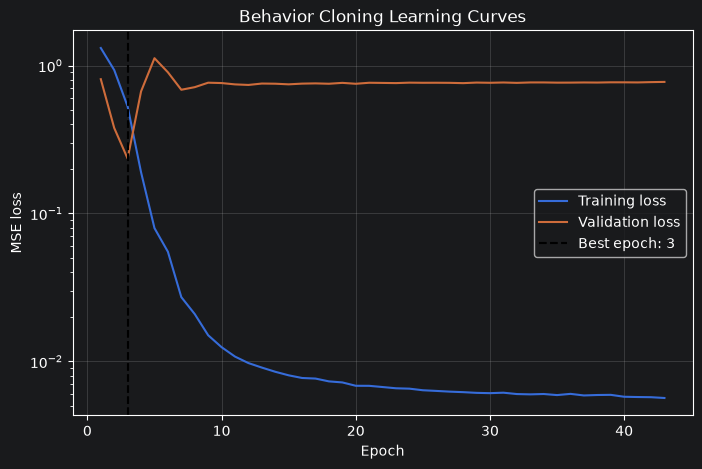

In [18]:
import matplotlib.pyplot as plt


epochs = np.arange(
    1,
    len(train_losses) + 1,
)


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    color="black",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Behavior Cloning Learning Curves")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [19]:
checkpoint_directory = (
    project_root / "checkpoints"
)

checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True,
)


checkpoint_path = (
    checkpoint_directory
    / "pickcube_bc_best.pt"
)


torch.save(
    {
        "model_state_dict": model.state_dict(),

        "observation_mean": torch.from_numpy(
            observation_mean.astype(np.float32)
        ),

        "observation_std": torch.from_numpy(
            observation_std.astype(np.float32)
        ),

        "observation_dim": 42,
        "action_dim": 8,
        "hidden_dim": 64,

        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,

        "training_episodes": training_episodes,
        "validation_episodes": validation_episodes,
    },
    checkpoint_path,
)


print("Saved checkpoint:", checkpoint_path)

Saved checkpoint: /home/bowenyuan/Projects/embodied-ai-learning/checkpoints/pickcube_bc_best.pt


在继续 2.8.8 闭环部署前，先回答两个问题：

1. epoch 3 的模型是否比"永远输出训练集平均动作"的简单 baseline 更好？
2. 8 个动作维度中，究竟是哪几个维度泛化最差？

两个问题的答案都不乐观：模型输给了常数 baseline，且误差集中在少数几个维度。这决定了下一步——不是换模型，而是换数据规模。


### 恢复最佳模型并与 mean-action baseline 比较

先把 checkpoint 恢复到 `best_model_state`，再和"永远输出训练集动作均值"的常数 baseline 比较。

这一步是必需的：MSE 本身没有尺度参照，`0.2350` 算好还是算坏，只有和 baseline 比才知道。

| 预测器 | validation MSE |
|---|---|
| best BC model（epoch 3） | `0.2350` |
| mean-action baseline | `0.1421` |
| 差值（模型 − baseline） | **`+0.0929`，即模型更差** |

模型输给了一个完全不做输入处理的常数预测器，说明它还没有学到可迁移的 state → action 关系。


In [20]:
assert best_model_state is not None

model.load_state_dict(best_model_state)
model.eval()


validation_predictions = []
validation_targets = []


with torch.no_grad():
    for observations, expert_actions in validation_loader:
        observations = observations.to(device)

        predicted_actions = model(observations)

        validation_predictions.append(
            predicted_actions.cpu()
        )

        validation_targets.append(
            expert_actions.cpu()
        )


validation_predictions = torch.cat(
    validation_predictions,
    dim=0,
).numpy()

validation_targets = torch.cat(
    validation_targets,
    dim=0,
).numpy()


model_validation_mse = np.mean(
    (
        validation_predictions
        - validation_targets
    ) ** 2
)


# A naive baseline that always predicts
# the mean training action
mean_training_action = train_actions.mean(
    axis=0,
    keepdims=True,
)

baseline_predictions = np.repeat(
    mean_training_action,
    repeats=len(validation_actions),
    axis=0,
)

baseline_validation_mse = np.mean(
    (
        baseline_predictions
        - validation_actions
    ) ** 2
)


print("Best BC validation MSE :", model_validation_mse)
print("Mean-action baseline MSE:", baseline_validation_mse)

print(
    "Improvement over baseline:",
    baseline_validation_mse
    - model_validation_mse,
)

Best BC validation MSE : 0.23502295
Mean-action baseline MSE: 0.14210252
Improvement over baseline: -0.09292042


### 检查每个动作维度

整体 MSE 可能被少数维度主导，所以要逐维拆开。实际结果里误差集中在 `joint_4`（`0.570`）、`gripper`（`0.561`）和 `joint_2`（`0.409`）；`joint_5` 的 MSE 虽小（`0.019`），但它的 target std 也只有 `0.0023`，必须和 std 一起看才有意义。


RMSE 是 MSE 的平方根，因此与动作本身的单位一致，便于和该维度的 target std 直接比较：RMSE 明显大于 std，说明该维度基本没有被学到。


In [21]:
action_names = [
    "joint_1",
    "joint_2",
    "joint_3",
    "joint_4",
    "joint_5",
    "joint_6",
    "joint_7",
    "gripper",
]


per_action_mse = np.mean(
    (
        validation_predictions
        - validation_targets
    ) ** 2,
    axis=0,
)

per_action_rmse = np.sqrt(per_action_mse)


print(
    f"{'Action':<12}"
    f"{'MSE':>12}"
    f"{'RMSE':>12}"
    f"{'Target std':>14}"
)

for index, name in enumerate(action_names):
    print(
        f"{name:<12}"
        f"{per_action_mse[index]:>12.6f}"
        f"{per_action_rmse[index]:>12.6f}"
        f"{validation_targets[:, index].std():>14.6f}"
    )

Action               MSE        RMSE    Target std
joint_1         0.012036    0.109708      0.043587
joint_2         0.409044    0.639566      0.241712
joint_3         0.029163    0.170772      0.018589
joint_4         0.570398    0.755247      0.120450
joint_5         0.018995    0.137824      0.002341
joint_6         0.152755    0.390839      0.132008
joint_7         0.126312    0.355404      0.057061
gripper         0.561481    0.749320      0.994444


### 检查 validation observation 是否超出训练范围

标准化的均值和标准差来自训练集。如果验证 episode 的 state 在某个维度上远离训练分布，标准化后的数值会异常大——这是一个可以直接量化的 distribution shift 信号。

实际结果：validation 样本的最大 `|z|` 达到 **13.21**（第 39 维，其训练 std 只有 `0.0088`）。也就是说，部署时模型看到的状态有一部分已经离训练分布很远；这正是 2.8.8 闭环执行会迅速发散的前兆。


In [22]:
maximum_absolute_z = np.max(
    np.abs(normalized_validation_observations),
    axis=0,
)

largest_dimensions = np.argsort(
    maximum_absolute_z
)[::-1][:10]


print(
    f"{'Dimension':<12}"
    f"{'Max |z|':>12}"
    f"{'Train std':>14}"
)

for index in largest_dimensions:
    print(
        f"{index:<12}"
        f"{maximum_absolute_z[index]:>12.4f}"
        f"{observation_std[0, index]:>14.8f}"
    )

Dimension        Max |z|     Train std
39               13.2084    0.00875096
17               11.6160    0.02687092
16                8.1639    0.03020374
34                5.3329    0.00092416
33                4.2029    0.00100102
31                3.2145    0.07168695
10                3.1860    0.21421318
1                 3.0291    0.17716205
27                2.9106    0.03092669
12                2.8868    0.10678365


## 2.8.8 — 策略部署与闭环执行


### 1. 单步预测与闭环执行的区别

Validation 做的是单步预测：

```text
专家 observation → policy → predicted action → 与 expert action 比较
```

每次输入都来自专家轨迹，所以即使上一步预测错了，也不会影响下一个输入。

闭环执行则是：

```text
环境状态 o_t → policy(o_t) → predicted action → env.step(action)
→ 模型自己造成的新状态 o_(t+1) → 再预测
```

模型必须承受自己之前动作产生的后果。这就是本节要检验的东西：**验证 Loss 低也不能推出"能完成任务"**，只有当 policy 的输出去驱动环境、并用任务成功率判定时，才知道它是否可用。


### 2. 配置评测环境

部署环境必须与示范数据一致：`obs_mode="state"`、`control_mode="pd_joint_pos"`（与 expert episode 的采集模式相同），并断言 observation 是 42 维、action 是 8 维。

这一致性是结论成立的前提：如果这里误用 `pd_joint_delta_pos`，训练好的动作语义会整体错位，而形状检查仍然会通过。


In [23]:
import gymnasium as gym
import mani_skill.envs
import numpy as np
import torch


test_seed = 100
maximum_steps = 200


evaluation_env = gym.make(
    "PickCube-v1",

    # State observation, expected dimension: 42
    obs_mode="state",

    # Must match the expert demonstrations
    control_mode="pd_joint_pos",

    # No visualization during the first diagnostic
    render_mode=None,
)


observation, reset_info = evaluation_env.reset(
    seed=test_seed
)


print("Observation type :", type(observation))
print("Observation shape:", observation.shape)
print("Action shape     :", evaluation_env.action_space.shape)
print("Action low       :", evaluation_env.action_space.low)
print("Action high      :", evaluation_env.action_space.high)

Observation type : <class 'torch.Tensor'>
Observation shape: torch.Size([1, 42])
Action shape     : (8,)
Action low       : [-2.8973 -1.7628 -2.8973 -3.0718 -2.8973 -0.0175 -2.8973 -1.    ]
Action high      : [ 2.8973  1.7628  2.8973 -0.0698  2.8973  3.7525  2.8973  1.    ]


In [24]:
observation_size = int(
    np.prod(observation.shape)
)

action_size = int(
    np.prod(evaluation_env.action_space.shape)
)


assert observation_size == 42, (
    f"Expected 42 observation values, "
    f"received shape {observation.shape}"
)

assert action_size == 8, (
    f"Expected 8 action values, "
    f"received shape "
    f"{evaluation_env.action_space.shape}"
)

### 3. 准备部署所需对象

部署阶段必须使用**与训练完全相同**的预处理：训练集的 mean/std 张量、action space 的上下界，以及恢复后的 best checkpoint。任何一处不一致，都会让"模型失败"这个结论失去意义——因为失败可能只是预处理不一致造成的，而不是 policy 本身的问题。


In [25]:
assert best_model_state is not None

model.load_state_dict(best_model_state)
model.eval()


observation_mean_tensor = torch.as_tensor(
    observation_mean,
    dtype=torch.float32,
    device=device,
)

observation_std_tensor = torch.as_tensor(
    observation_std,
    dtype=torch.float32,
    device=device,
)


action_low_tensor = torch.as_tensor(
    evaluation_env.action_space.low,
    dtype=torch.float32,
    device=device,
).reshape(1, -1)


action_high_tensor = torch.as_tensor(
    evaluation_env.action_space.high,
    dtype=torch.float32,
    device=device,
).reshape(1, -1)


print("Normalization shape:", observation_mean_tensor.shape)
print("Action bounds shape :", action_low_tensor.shape)

Normalization shape: torch.Size([1, 42])
Action bounds shape : torch.Size([1, 8])


### 4. 单步推理函数


In [26]:
def predict_action(
    model,
    observation,
    observation_mean_tensor,
    observation_std_tensor,
    action_low_tensor,
    action_high_tensor,
    device,
):
    # Convert environment observation to a tensor
    if isinstance(observation, torch.Tensor):
        observation_tensor = (
            observation
            .detach()
            .to(device=device, dtype=torch.float32)
        )
    else:
        observation_tensor = torch.as_tensor(
            observation,
            dtype=torch.float32,
            device=device,
        )

    # Ensure the batch shape is [1, 42]
    observation_tensor = observation_tensor.reshape(
        1,
        -1,
    )

    assert observation_tensor.shape == (1, 42)


    # Apply exactly the same normalization as training
    normalized_observation = (
        observation_tensor
        - observation_mean_tensor
    ) / observation_std_tensor


    # Inference: do not calculate gradients
    with torch.no_grad():
        raw_action = model(
            normalized_observation
        )


    # Keep every action inside the environment limits
    clipped_action = torch.maximum(
        torch.minimum(
            raw_action,
            action_high_tensor,
        ),
        action_low_tensor,
    )


    was_clipped = not torch.allclose(
        raw_action,
        clipped_action,
    )


    return (
        raw_action,
        clipped_action,
        was_clipped,
    )

这里执行了三件重要的事：

```text
原始 observation
→ 使用训练统计量标准化
→ model.eval() + torch.no_grad() 预测
→ 裁剪到 action space
```

动作裁剪是安全边界：

$$ a_{\mathrm{safe}} = \min(\max(\hat a, a_{\mathrm{low}}), a_{\mathrm{high}}) $$

它只能防止动作越界，不能把错误动作变成正确动作。因此后面不仅记录成功与否，也记录每一步是否被裁剪——裁剪率高本身就是"模型输出已不可信"的证据。


### 5. 处理 NumPy、Torch 与布尔值

ManiSkill 在不同位置可能返回 NumPy 数组，也可能返回 Torch tensor，`reward` / `terminated` 之类的标量还常常是单元素 tensor。写两个辅助函数把它们统一成 Python 标量，可以避免在记录 rollout 时因为类型差异而误判（例如 `bool(tensor([False]))` 这类含糊写法）。


In [27]:
def action_for_environment(
    action_tensor,
    observation,
    action_shape,
):
    action_tensor = action_tensor.reshape(
        action_shape
    )

    if isinstance(observation, torch.Tensor):
        return action_tensor.to(
            observation.device
        )

    return action_tensor.detach().cpu().numpy()


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().reshape(-1)[0].item()

    array = np.asarray(value)

    return array.reshape(-1)[0].item()

### 6. 第一次 rollout：50 步

先按默认设置跑一次：`seed=100` 是一条**未见过的** episode，`model.eval()`，使用与训练相同的归一化，并把动作裁剪到 action space。循环里同时统计总 reward、被裁剪的步数、success 以及 episode 的终止原因。


In [28]:
observation, reset_info = evaluation_env.reset(
    seed=test_seed
)


total_reward = 0.0
clipped_steps = 0
success = False
termination_reason = "maximum steps reached"


for step in range(1, maximum_steps + 1):
    raw_action, clipped_action, was_clipped = (
        predict_action(
            model=model,
            observation=observation,
            observation_mean_tensor=(
                observation_mean_tensor
            ),
            observation_std_tensor=(
                observation_std_tensor
            ),
            action_low_tensor=action_low_tensor,
            action_high_tensor=action_high_tensor,
            device=device,
        )
    )


    if was_clipped:
        clipped_steps += 1


    environment_action = action_for_environment(
        action_tensor=clipped_action,
        observation=observation,
        action_shape=evaluation_env.action_space.shape,
    )


    (
        next_observation,
        reward,
        terminated,
        truncated,
        info,
    ) = evaluation_env.step(environment_action)


    reward_value = float(
        to_python_scalar(reward)
    )

    terminated_value = bool(
        to_python_scalar(terminated)
    )

    truncated_value = bool(
        to_python_scalar(truncated)
    )

    success_value = bool(
        to_python_scalar(
            info.get("success", False)
        )
    )


    total_reward += reward_value
    observation = next_observation


    if (
        step == 1
        or step % 20 == 0
        or success_value
        or terminated_value
        or truncated_value
    ):
        print(
            f"Step {step:03d} | "
            f"reward={reward_value:.4f} | "
            f"success={success_value} | "
            f"clipped={was_clipped}"
        )


    if success_value:
        success = True
        termination_reason = "task success"
        break

    if terminated_value:
        termination_reason = "environment terminated"
        break

    if truncated_value:
        termination_reason = "environment truncated"
        break


print("----------------")
print("Test seed         :", test_seed)
print("Steps             :", step)
print("Total reward      :", total_reward)
print("Success           :", success)
print("Clipped steps     :", clipped_steps)
print("Termination reason:", termination_reason)

Step 001 | reward=0.0595 | success=False | clipped=False
Step 020 | reward=0.0000 | success=False | clipped=True
Step 040 | reward=0.0000 | success=False | clipped=True
Step 050 | reward=0.0000 | success=False | clipped=True
----------------
Test seed         : 100
Steps             : 50
Total reward      : 0.32771512573321626
Success           : False
Clipped steps     : 49
Termination reason: environment truncated


#### 第一次结果与一个必须排除的解释

```text
Test seed         : 100
Steps             : 50
Success           : False
Clipped steps     : 49
Termination reason: environment truncated
```

失败可以有多种解释，其中一种与 policy 无关：**episode 可能只是被时间上限截断了**（`truncated`，而不是任务失败）。`gymnasium` 默认给 `PickCube-v1` 套了 50 步的 `TimeLimit`，所以必须先排除这一点，再谈"policy 不行"。


In [36]:
evaluation_env.close()

### 7. 排除时间上限：把 limit 从 50 改成 200

`gym.make(..., max_episode_steps=200)` 确实生效了，但从 `env.spec.max_episode_steps` 上看不出来——它打印为 `None`，因为真正决定上限的是 wrapper 上的 `_max_episode_steps`，位于包装链里而不是 `env.spec` 上。因此下面逐层打印 wrapper，定位到 `TimeLimitWrapper` 并读取它实际使用的上限，确认生效值是 200。

这一步本身就是实验设计的一部分：**先排除一个与假设无关的解释，再下结论。**


In [37]:
evaluation_env = gym.make(
    "PickCube-v1",
    obs_mode="state",
    control_mode="pd_joint_pos",
    render_mode=None,

    # Override the default 50-step TimeLimit
    max_episode_steps=200,
)


observation, reset_info = evaluation_env.reset(
    seed=100
)


action_low_tensor = torch.as_tensor(
    evaluation_env.action_space.low,
    dtype=torch.float32,
    device=device,
).reshape(1, -1)

action_high_tensor = torch.as_tensor(
    evaluation_env.action_space.high,
    dtype=torch.float32,
    device=device,
).reshape(1, -1)


print(
    "Environment maximum steps:",
    evaluation_env.spec.max_episode_steps,
)

Environment maximum steps: None


In [38]:
print("Environment wrapper:")
print(evaluation_env)

print(
    "spec.max_episode_steps:",
    getattr(
        evaluation_env.spec,
        "max_episode_steps",
        None,
    ),
)

print(
    "wrapper._max_episode_steps:",
    getattr(
        evaluation_env,
        "_max_episode_steps",
        None,
    ),
)

Environment wrapper:
<TimeLimitWrapper<OrderEnforcing<PickCubeEnv<PickCube-v1>>>>
spec.max_episode_steps: None
wrapper._max_episode_steps: 200


In [39]:
def find_time_limit_wrapper(env):
    current_env = env

    for depth in range(10):
        print(
            f"Layer {depth}:",
            type(current_env).__name__,
            "limit=",
            getattr(
                current_env,
                "_max_episode_steps",
                None,
            ),
        )

        if hasattr(
            current_env,
            "_max_episode_steps",
        ):
            return current_env

        if not hasattr(current_env, "env"):
            break

        current_env = current_env.env

    return None


time_limit_wrapper = find_time_limit_wrapper(
    evaluation_env
)


assert time_limit_wrapper is not None, (
    "Could not find ManiSkill TimeLimit wrapper."
)


print(
    "Effective episode limit:",
    time_limit_wrapper._max_episode_steps,
)

Layer 0: TimeLimitWrapper limit= 200
Effective episode limit: 200


In [40]:
test_seed = 100
maximum_steps = 200


observation, reset_info = evaluation_env.reset(
    seed=test_seed
)


total_reward = 0.0
clipped_steps = 0
success = False
termination_reason = "maximum steps reached"

raw_action_history = []
clipped_action_history = []


for step in range(1, maximum_steps + 1):
    raw_action, clipped_action, was_clipped = (
        predict_action(
            model=model,
            observation=observation,
            observation_mean_tensor=(
                observation_mean_tensor
            ),
            observation_std_tensor=(
                observation_std_tensor
            ),
            action_low_tensor=action_low_tensor,
            action_high_tensor=action_high_tensor,
            device=device,
        )
    )


    raw_action_history.append(
        raw_action
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )

    clipped_action_history.append(
        clipped_action
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )


    if was_clipped:
        clipped_steps += 1


    environment_action = action_for_environment(
        action_tensor=clipped_action,
        observation=observation,
        action_shape=evaluation_env.action_space.shape,
    )


    (
        next_observation,
        reward,
        terminated,
        truncated,
        info,
    ) = evaluation_env.step(environment_action)


    reward_value = float(
        to_python_scalar(reward)
    )

    terminated_value = bool(
        to_python_scalar(terminated)
    )

    truncated_value = bool(
        to_python_scalar(truncated)
    )

    success_value = bool(
        to_python_scalar(
            info.get("success", False)
        )
    )


    total_reward += reward_value
    observation = next_observation


    if (
        step == 1
        or step % 20 == 0
        or success_value
        or terminated_value
        or truncated_value
    ):
        print(
            f"Step {step:03d} | "
            f"reward={reward_value:.4f} | "
            f"success={success_value} | "
            f"clipped={was_clipped}"
        )


    if success_value:
        success = True
        termination_reason = "task success"
        break

    if terminated_value:
        termination_reason = "environment terminated"
        break

    if truncated_value:
        termination_reason = "environment truncated"
        break


print("----------------")
print("Test seed         :", test_seed)
print("Steps             :", step)
print("Total reward      :", total_reward)
print("Success           :", success)
print("Clipped steps     :", clipped_steps)
print("Termination reason:", termination_reason)

Step 001 | reward=0.0595 | success=False | clipped=False
Step 020 | reward=0.0000 | success=False | clipped=True
Step 040 | reward=0.0000 | success=False | clipped=True
Step 060 | reward=0.0000 | success=False | clipped=True
Step 080 | reward=0.0000 | success=False | clipped=True
Step 100 | reward=0.0000 | success=False | clipped=True
Step 120 | reward=0.0000 | success=False | clipped=True
Step 140 | reward=0.0000 | success=False | clipped=True
Step 160 | reward=0.0000 | success=False | clipped=True
Step 180 | reward=0.0000 | success=False | clipped=True
Step 200 | reward=0.0000 | success=False | clipped=True
----------------
Test seed         : 100
Steps             : 200
Total reward      : 0.32771512573321626
Success           : False
Clipped steps     : 199
Termination reason: environment truncated


#### 第二次结果：200 步

```text
Step 001 | reward=0.0595 | success=False | clipped=False
Step 020 | reward=0.0000 | success=False | clipped=True
...
Step 200 | reward=0.0000 | success=False | clipped=True
Success: False
```

reward 在第 20 步左右就掉到 0 并保持到第 200 步。把上限放大四倍并没有改变结果，因此"任务未完成"不是时间不够，而是 policy 在很早的阶段就离开了有效状态区域。


In [41]:
raw_action_history = np.stack(
    raw_action_history
)

clipped_action_history = np.stack(
    clipped_action_history
)


clipping_mask = (
    np.abs(
        raw_action_history
        - clipped_action_history
    )
    > 1e-6
)


clipping_count_by_action = clipping_mask.sum(
    axis=0
)


for name, count in zip(
    action_names,
    clipping_count_by_action,
):
    print(
        f"{name:<10}: "
        f"{count:>3} / {len(raw_action_history)} steps"
    )

joint_1   : 149 / 200 steps
joint_2   : 199 / 200 steps
joint_3   : 129 / 200 steps
joint_4   : 199 / 200 steps
joint_5   : 101 / 200 steps
joint_6   : 199 / 200 steps
joint_7   : 199 / 200 steps
gripper   : 199 / 200 steps


#### 每个动作维度的越界情况

```text
joint_1   : 149 / 200 steps
joint_2   : 199 / 200 steps
joint_3   : 129 / 200 steps
joint_4   : 199 / 200 steps
joint_5   : 101 / 200 steps
joint_6   : 199 / 200 steps
joint_7   : 199 / 200 steps
gripper   : 199 / 200 steps
```

绝大多数维度在 `199/200` 步都被裁剪，说明模型输出的原始动作几乎一直落在合法范围之外。clipping 在这里起的是**安全**作用：它挡住了越界动作，但没有把错误动作变成正确动作。


## 2.8 — 结论（正式记录）

> The BC model fitted the four training demonstrations but failed to generalize to an unseen episode. Its best validation MSE (0.2350) was worse than the mean-action baseline (0.1421). During closed-loop rollout on unseen seed 100, the policy failed to complete the task and produced out-of-range actions on 199 of 200 steps, demonstrating severe overfitting and compounding distribution shift.

**这不是训练代码失败。** 训练代码完成了它该做的工作：

- training loss 下降 → 优化器、反向传播、数据通路都正确；
- validation 揭示过拟合 → 评估流程有效；
- early stopping 保存最佳 epoch → 没有使用退化的最后一步；
- baseline 比较揭示没有泛化 → 指标有参照物；
- closed-loop rollout 判定任务未完成 → 结论来自任务成功，而不是 loss；
- action clipping 防止动作越界 → 安全边界生效；
- 50 步与 200 步对照 → 排除了"时间上限"这一替代解释。

**当前模型是一个有效的失败基线（failure baseline），不是可用 policy。**

如果目标是得到真正可工作的 BC policy，下一轮应该把 expert 数据扩到至少 30–50 条 episode，再用同样的 episode-level split 重新训练。这属于数据规模化与策略改进，而不是修复当前训练代码。

下一章：**Lesson 3 — 模仿学习与行为克隆**，入口实验正是这里的实测结果（过拟合、baseline、distribution shift）。
